# ASR benchmark: model comparison

Compares every run under `results/` (one folder per model, one CSV per dataset, as written by `run_bench.py`).
The typical question is: **did fine-tuning improve on the base model, and which hyperparameter variant is best?**

Sections:
1. Data coverage: which model was evaluated on which dataset
2. Leaderboard: corpus WER per model and dataset
3. WER per dataset with 95% confidence intervals
4. Relative WER change vs. the baseline
5. Error breakdown: substitutions, deletions, insertions
6. Paired significance: is the difference real or noise?
7. Per-utterance win/tie/loss vs. the baseline
8. WER by utterance length
9. Speed (real-time factor) and speed vs. accuracy
10. Biggest improvements and regressions (qualitative check)

**How WER is computed here.** All WER values are *corpus-level*: total errors / total reference words,
`(S + D + I) / (H + S + D)`, over the normalized text, which gives the same number as `jiwer` and
`evaluate_model.py`. It is **not** the mean of per-utterance WER. That mean over-weights short clips,
where one wrong word can mean 50% WER.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

# ---- configuration ---------------------------------------------------------
RESULTS_DIR = Path("../results")

# The reference model everything is compared against (a folder name in RESULTS_DIR).
BASELINE = "rerun-ivrit-lv3-mlx"

# Optional: fixed display order / short labels. Models not listed are appended alphabetically.
MODEL_ORDER = [
    "rerun-ivrit-lv3-mlx",
    "lv3-mix-b32-kd-low-smooth-mlx",
    "lv3-mix-na-b32-kd-low-smooth-mlx",

    # Extra
    "rerun-lv3-mix-b64-kd-mlx"
]
MODEL_LABELS = {
    "rerun-ivrit-lv3-mlx": "baseline (ivrit large-v3)",
}

N_BOOTSTRAP = 2000  # resamples for confidence intervals / paired tests
RNG = np.random.default_rng(0)

In [2]:
# ---- plot style --------------------------------------------------------------
# Categorical colors in a fixed order (colorblind-validated for up to 3 series together).
# Color follows the model, never its rank, so each model keeps one color in every chart.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TEXT, TEXT_MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
DIVERGING = ["#2a78d6", "#f0efec", "#e34948"]  # better (blue) <-> neutral <-> worse (red)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.labelcolor": TEXT_MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "legend.frameon": False,
    "lines.linewidth": 2,
})
pct = mticker.PercentFormatter(xmax=1, decimals=0)

## Load all results

In [3]:
frames = []
for csv in sorted(RESULTS_DIR.glob("*/*.csv")):
    df = pd.read_csv(csv)
    df["model_name"] = csv.parent.name
    df["dataset_name"] = csv.stem
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
raw["n_ref_words"] = raw["hits"] + raw["substitutions"] + raw["deletions"]
raw["n_errors"] = raw["substitutions"] + raw["deletions"] + raw["insertions"]

found = sorted(raw["model_name"].unique())
MODELS = [m for m in MODEL_ORDER if m in found] + [m for m in found if m not in MODEL_ORDER]
assert BASELINE in MODELS, f"BASELINE {BASELINE!r} not found in {RESULTS_DIR}"
DATASETS = sorted(raw["dataset_name"].unique())
COLOR = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(MODELS)}
label = lambda m: MODEL_LABELS.get(m, m)

print(f"{len(MODELS)} models, {len(DATASETS)} datasets, {len(raw):,} utterances")

4 models, 5 datasets, 23,396 utterances


## 1. Data coverage
Check this first. A model missing a dataset can't be compared on it, and the averages below only use
datasets that **every** model was evaluated on.

In [4]:
coverage = raw.groupby(["dataset_name", "model_name"]).agg(
    utterances=("id", "size"), hours=("audio_duration", lambda s: s.sum() / 3600)
)
cov_table = coverage["utterances"].unstack()[MODELS].rename(columns=label)
display(cov_table.fillna("missing"))

COMMON_DATASETS = [d for d in DATASETS if coverage.xs(d, level=0).index.nunique() == len(MODELS)]
missing = sorted(set(DATASETS) - set(COMMON_DATASETS))
print("Datasets shared by all models:", COMMON_DATASETS)
if missing:
    print("Excluded from averages (not run on every model):", missing)

# Paired comparisons need the same utterances; flag mismatches.
for d in COMMON_DATASETS:
    ids = [set(raw.query("dataset_name == @d and model_name == @m")["id"]) for m in MODELS]
    if any(s != ids[0] for s in ids):
        print(f"WARNING: {d} has different utterance ids across models")

model_name,baseline (ivrit large-v3),lv3-mix-b32-kd-low-smooth-mlx,lv3-mix-na-b32-kd-low-smooth-mlx,rerun-lv3-mix-b64-kd-mlx
dataset_name,,,,
fleurs,792,792,792,792
hebrew_speech_kan,2000,2000,2000,2000
ivrit_ai_eval_d1,17,17,17,17
ivrit_ai_eval_whatsapp,54,54,54,54
saspeech,2986,2986,2986,2986


Datasets shared by all models: ['fleurs', 'hebrew_speech_kan', 'ivrit_ai_eval_d1', 'ivrit_ai_eval_whatsapp', 'saspeech']


## 2. Leaderboard (corpus WER)
Lower is better. The best model per dataset is highlighted. `avg (macro)` is the plain mean over the shared
datasets, so each dataset counts equally. `avg (pooled)` pools all words together, so large datasets dominate it.

In [5]:
def corpus_wer(df):
    return df["n_errors"].sum() / df["n_ref_words"].sum()

wer = raw.groupby(["dataset_name", "model_name"]).apply(corpus_wer, include_groups=False).unstack()[MODELS]

board = wer.copy()
board.loc["avg (macro)"] = wer.loc[COMMON_DATASETS].mean()
board.loc["avg (pooled)"] = [corpus_wer(raw[(raw.model_name == m) & raw.dataset_name.isin(COMMON_DATASETS)]) for m in MODELS]

display(
    board.rename(columns=label)
    .style.format("{:.2%}", na_rep="n/a")
    .highlight_min(axis=1, props="font-weight: bold; background-color: #cde2fb")
)

model_name,baseline (ivrit large-v3),lv3-mix-b32-kd-low-smooth-mlx,lv3-mix-na-b32-kd-low-smooth-mlx,rerun-lv3-mix-b64-kd-mlx
dataset_name,,,,
fleurs,17.69%,17.37%,17.43%,17.64%
hebrew_speech_kan,8.27%,8.32%,8.08%,8.20%
ivrit_ai_eval_d1,5.01%,5.15%,5.05%,5.08%
ivrit_ai_eval_whatsapp,7.01%,6.79%,7.93%,6.95%
saspeech,6.52%,6.49%,6.45%,6.53%
avg (macro),8.90%,8.82%,8.99%,8.88%
avg (pooled),8.54%,8.48%,8.54%,8.53%


## 3. WER per dataset, with 95% confidence intervals
Error bars come from bootstrapping over utterances. **If two models' intervals overlap a lot, the difference
may be noise.** This matters most on small test sets: `ivrit_ai_eval_d1` has only 17 (long) utterances.
Section 6 has the more exact paired test.

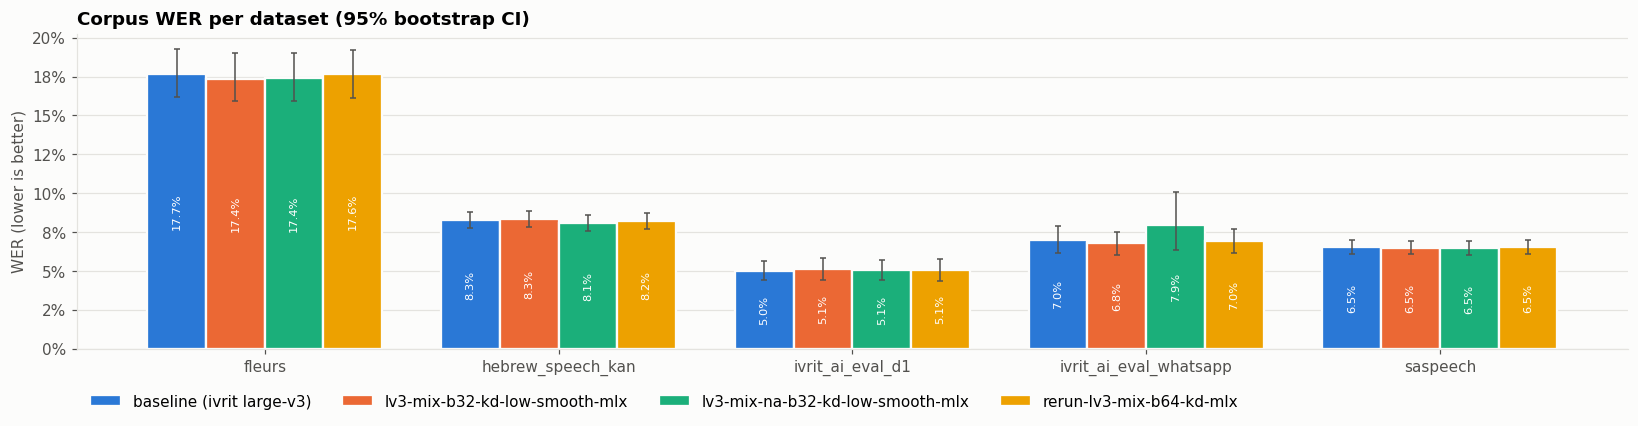

In [6]:
def bootstrap_wer_ci(df, n=N_BOOTSTRAP, alpha=0.05):
    e, w = df["n_errors"].to_numpy(), df["n_ref_words"].to_numpy()
    idx = RNG.integers(0, len(df), size=(n, len(df)))
    samples = e[idx].sum(1) / w[idx].sum(1)
    return np.quantile(samples, [alpha / 2, 1 - alpha / 2])

ci = {
    (d, m): bootstrap_wer_ci(g)
    for (d, m), g in raw.groupby(["dataset_name", "model_name"])
}

fig, ax = plt.subplots(figsize=(15, 4))
width = 0.8 / len(MODELS)
x = np.arange(len(DATASETS))
for i, m in enumerate(MODELS):
    vals = wer.loc[DATASETS, m].to_numpy()
    lo = [vals[j] - ci[(d, m)][0] if (d, m) in ci else 0 for j, d in enumerate(DATASETS)]
    hi = [ci[(d, m)][1] - vals[j] if (d, m) in ci else 0 for j, d in enumerate(DATASETS)]
    pos = x - 0.4 + width * (i + 0.5)
    ax.bar(pos, vals, width, color=COLOR[m], label=label(m), edgecolor=SURFACE, linewidth=1.5)
    ax.errorbar(pos, vals, yerr=[lo, hi], fmt="none", ecolor=TEXT_MUTED, elinewidth=1, capsize=2)
    for p, v in zip(pos, vals):
        if np.isnan(v):
            ax.text(p, 0.002, "n/a", ha="center", va="bottom", fontsize=8, color=TEXT_MUTED, rotation=90)
        else:
            ax.text(p, v / 2, f"{v:.1%}", ha="center", va="center", fontsize=7.5, color="white", rotation=90)
ax.set_xticks(x, DATASETS)
ax.yaxis.set_major_formatter(pct)
ax.set_ylabel("WER (lower is better)")
ax.set_title("Corpus WER per dataset (95% bootstrap CI)")
ax.legend(ncols=len(MODELS), loc="upper left", bbox_to_anchor=(0, -0.1))
plt.tight_layout()
plt.show()

## 4. Relative WER change vs. the baseline
`(WER_model − WER_baseline) / WER_baseline`. **Blue means fewer errors than the baseline and red means more.**
This is the usual way to report fine-tuning gains ("-30% relative WER"), because it makes datasets with very
different absolute WER comparable.

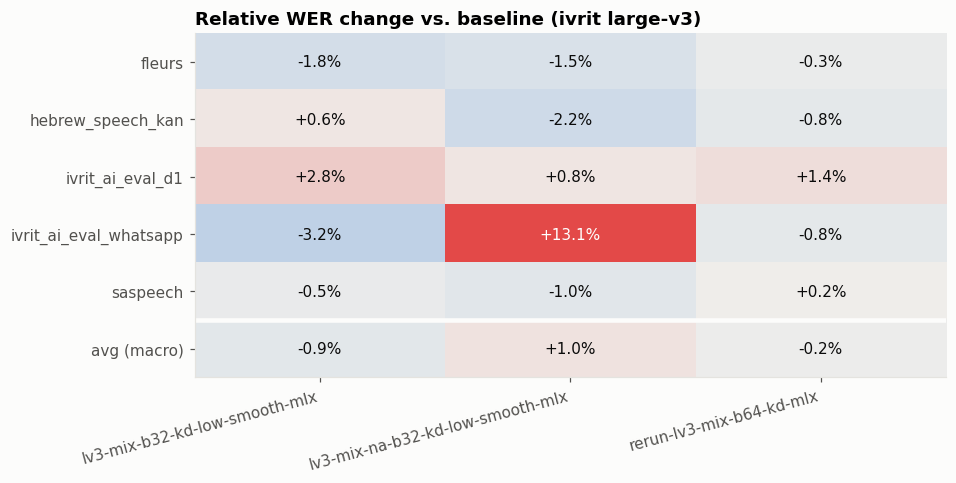

In [7]:
others = [m for m in MODELS if m != BASELINE]
rel = wer[others].sub(wer[BASELINE], axis=0).div(wer[BASELINE], axis=0)
rel.loc["avg (macro)"] = board.loc["avg (macro)", others] / board.loc["avg (macro)", BASELINE] - 1

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
cmap = LinearSegmentedColormap.from_list("div", DIVERGING)
lim = max(np.nanmax(np.abs(rel.to_numpy())), 0.05)

fig, ax = plt.subplots(figsize=(2.2 + 2.2 * len(others), 0.55 * len(rel) + 1.2))
ax.imshow(rel.to_numpy(dtype=float), cmap=cmap, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
for (r, c), v in np.ndenumerate(rel.to_numpy(dtype=float)):
    txt = "no baseline" if np.isnan(v) else f"{v:+.1%}"
    strong = not np.isnan(v) and abs(v) > lim * 0.6
    ax.text(c, r, txt, ha="center", va="center", color="white" if strong else TEXT, fontsize=10)
ax.set_xticks(range(len(others)), [label(m) for m in others], rotation=15, ha="right")
ax.set_yticks(range(len(rel)), rel.index)
ax.axhline(len(rel) - 1.5, color=SURFACE, linewidth=3)
ax.grid(False)
ax.set_title(f"Relative WER change vs. {label(BASELINE)}")
plt.tight_layout()
plt.show()

## 5. Error breakdown: substitutions, deletions, insertions
Each panel is one error type, as a rate per reference word, so the three panels add up to the WER.
They point to different causes:
- **substitutions**: wrong word (spelling, vocabulary, acoustics)
- **deletions**: words skipped (often truncated or cut-off segments, or skipped repetitions)
- **insertions**: extra words (hallucinations, repeated loops, text in silence)

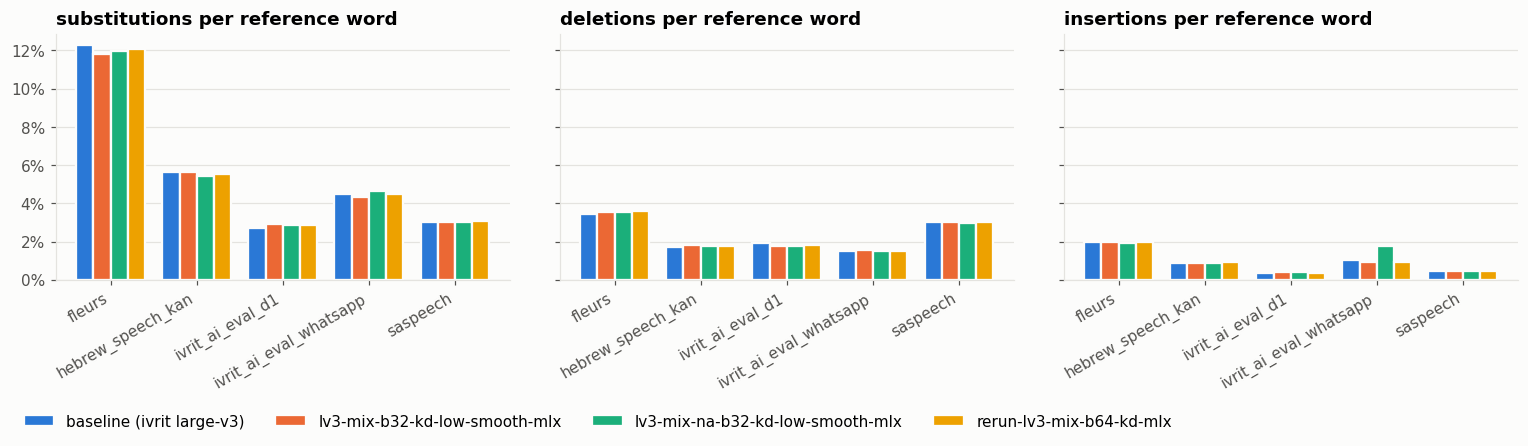

In [8]:
err = raw.groupby(["dataset_name", "model_name"])[["substitutions", "deletions", "insertions", "n_ref_words"]].sum()
for k in ["substitutions", "deletions", "insertions"]:
    err[k + "_rate"] = err[k] / err["n_ref_words"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, kind in zip(axes, ["substitutions", "deletions", "insertions"]):
    t = err[kind + "_rate"].unstack().reindex(index=DATASETS, columns=MODELS)
    for i, m in enumerate(MODELS):
        ax.bar(x - 0.4 + width * (i + 0.5), t[m], width, color=COLOR[m], label=label(m), edgecolor=SURFACE, linewidth=1.5)
    ax.set_xticks(x, DATASETS, rotation=30, ha="right")
    ax.set_title(f"{kind} per reference word")
    ax.yaxis.set_major_formatter(pct)
fig.legend(*axes[0].get_legend_handles_labels(), ncols=len(MODELS), loc="lower left", bbox_to_anchor=(0.01, -0.02))
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## 6. Paired significance test
Every model transcribed the **same** utterances, so a *paired* bootstrap is the standard test for ASR
(Bisani & Ney, 2004). It resamples utterances and recomputes the WER difference each time.
- `ΔWER`: absolute WER difference, row model minus column model (negative means the row model is better)
- `95% CI`: if it doesn't include 0, the difference is significant
- `p(better)`: fraction of resamples in which the row model wins

This is especially useful for choosing between two hyperparameter variants whose WERs are very close.

In [9]:
def paired_bootstrap(a, b, n=N_BOOTSTRAP):
    # a, b: per-utterance frames for two models on the same dataset
    j = a[["id", "n_errors", "n_ref_words"]].merge(b[["id", "n_errors"]], on="id", suffixes=("_a", "_b"))
    ea, eb, w = j["n_errors_a"].to_numpy(), j["n_errors_b"].to_numpy(), j["n_ref_words"].to_numpy()
    idx = RNG.integers(0, len(j), size=(n, len(j)))
    diff = (ea[idx].sum(1) - eb[idx].sum(1)) / w[idx].sum(1)
    return (ea.sum() - eb.sum()) / w.sum(), np.quantile(diff, [0.025, 0.975]), (diff < 0).mean()

rows = []
for d in DATASETS:
    present = [m for m in MODELS if (d, m) in ci]
    for i, ma in enumerate(present):
        for mb in present[i + 1:]:
            a = raw.query("dataset_name == @d and model_name == @ma")
            b = raw.query("dataset_name == @d and model_name == @mb")
            delta, (lo, hi), p = paired_bootstrap(b, a)  # b − a: negative means b is better
            rows.append({
                "dataset": d, "model": label(mb), "vs": label(ma),
                "ΔWER": delta, "95% CI": f"[{lo:+.2%}, {hi:+.2%}]", "p(better)": p,
                "significant": "yes" if (hi < 0 or lo > 0) else "no",
            })
sig = pd.DataFrame(rows)
display(
    sig.style.format({"ΔWER": "{:+.2%}", "p(better)": "{:.1%}"})
    .map(lambda v: "font-weight: bold" if v == "yes" else "", subset=["significant"])
)

,dataset,model,vs,ΔWER,95% CI,p(better),significant
0,fleurs,lv3-mix-b32-kd-low-smooth-mlx,baseline (ivrit large-v3),-0.33%,"[-0.57%, -0.08%]",99.2%,yes
1,fleurs,lv3-mix-na-b32-kd-low-smooth-mlx,baseline (ivrit large-v3),-0.26%,"[-0.52%, -0.01%]",97.9%,yes
2,fleurs,rerun-lv3-mix-b64-kd-mlx,baseline (ivrit large-v3),-0.06%,"[-0.28%, +0.17%]",68.8%,no
3,fleurs,lv3-mix-na-b32-kd-low-smooth-mlx,lv3-mix-b32-kd-low-smooth-mlx,+0.07%,"[-0.13%, +0.26%]",25.7%,no
4,fleurs,rerun-lv3-mix-b64-kd-mlx,lv3-mix-b32-kd-low-smooth-mlx,+0.27%,"[+0.01%, +0.51%]",1.7%,yes
5,fleurs,rerun-lv3-mix-b64-kd-mlx,lv3-mix-na-b32-kd-low-smooth-mlx,+0.20%,"[-0.05%, +0.44%]",6.2%,no
6,hebrew_speech_kan,lv3-mix-b32-kd-low-smooth-mlx,baseline (ivrit large-v3),+0.05%,"[-0.14%, +0.25%]",29.3%,no
7,hebrew_speech_kan,lv3-mix-na-b32-kd-low-smooth-mlx,baseline (ivrit large-v3),-0.18%,"[-0.39%, +0.03%]",94.2%,no
8,hebrew_speech_kan,rerun-lv3-mix-b64-kd-mlx,baseline (ivrit large-v3),-0.07%,"[-0.22%, +0.10%]",78.2%,no
9,hebrew_speech_kan,lv3-mix-na-b32-kd-low-smooth-mlx,lv3-mix-b32-kd-low-smooth-mlx,-0.23%,"[-0.42%, -0.06%]",99.5%,yes


## 7. Per-utterance win / tie / loss vs. the baseline
For each utterance: did the model make fewer errors than the baseline (win), more (loss), or the same (tie)?
This shows whether a WER gain is broad or comes from a few utterances.

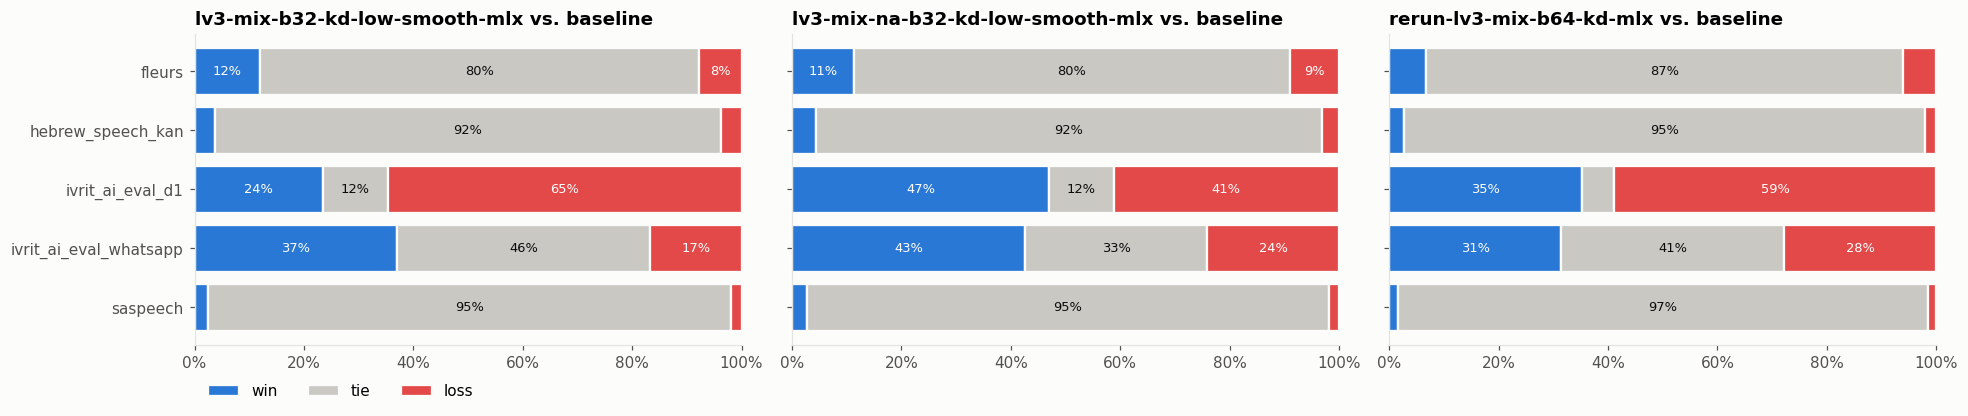

In [10]:
wtl_rows = []
for d in COMMON_DATASETS:
    base = raw.query("dataset_name == @d and model_name == @BASELINE")[["id", "n_errors"]]
    for m in others:
        j = raw.query("dataset_name == @d and model_name == @m")[["id", "n_errors"]].merge(base, on="id", suffixes=("", "_base"))
        diff = j["n_errors"] - j["n_errors_base"]
        wtl_rows.append({"dataset": d, "model": m, "win": (diff < 0).mean(), "tie": (diff == 0).mean(), "loss": (diff > 0).mean()})
wtl = pd.DataFrame(wtl_rows)

fig, axes = plt.subplots(1, len(others), figsize=(6 * len(others), 0.5 * len(COMMON_DATASETS) + 1.4), sharey=True, squeeze=False)
for ax, m in zip(axes[0], others):
    t = wtl[wtl.model == m].set_index("dataset").loc[COMMON_DATASETS]
    left = np.zeros(len(t))
    for col, color in [("win", DIVERGING[0]), ("tie", "#c9c8c3"), ("loss", DIVERGING[2])]:
        ax.barh(t.index, t[col], left=left, color=color, label=col, edgecolor=SURFACE, linewidth=1.5)
        for y, (l, v) in enumerate(zip(left, t[col])):
            if v > 0.07:
                ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                        color="white" if col != "tie" else TEXT)
        left += t[col].to_numpy()
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(pct)
    ax.grid(False)
    ax.invert_yaxis()
    ax.set_title(f"{label(m)} vs. baseline")
axes[0][0].legend(ncols=3, loc="upper left", bbox_to_anchor=(0, -0.08))
plt.tight_layout()
plt.show()

## 8. WER by utterance length
Fine-tuning often changes behavior on very short clips (more hallucinations or insertions) or on long ones
(drift, repetition loops). Uses pooled corpus WER per length bucket over the shared datasets. The number of
utterances in each bucket is shown under its label.

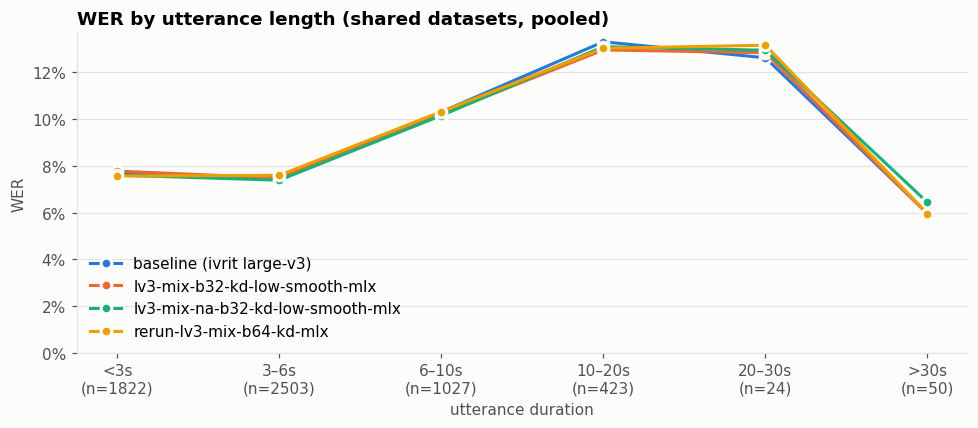

In [11]:
bins = [0, 3, 6, 10, 20, 30, np.inf]
names = ["<3s", "3–6s", "6–10s", "10–20s", "20–30s", ">30s"]
sub = raw[raw.dataset_name.isin(COMMON_DATASETS)].copy()
sub["length"] = pd.cut(sub["audio_duration"], bins=bins, labels=names, right=False)
by_len = sub.groupby(["length", "model_name"], observed=True).apply(corpus_wer, include_groups=False).unstack()[MODELS]
counts = sub[sub.model_name == BASELINE].groupby("length", observed=True).size()

fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(by_len))
for m in MODELS:
    ax.plot(xs, by_len[m], marker="o", markersize=7, color=COLOR[m], label=label(m),
            markeredgecolor=SURFACE, markeredgewidth=2)
ax.set_xticks(xs, [f"{n}\n(n={counts.get(n, 0)})" for n in by_len.index])
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(bottom=0)
ax.set_xlabel("utterance duration")
ax.set_ylabel("WER")
ax.set_title("WER by utterance length (shared datasets, pooled)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Speed (not really relevent, since different modes of gpu they should be about the same)
**Real-time factor (RTF)** = transcription time / audio duration. Lower is faster, and 0.25 means 4× faster
than real time. Only compare RTF between runs made on the same machine under similar load
(check `machine.json` in each results folder).

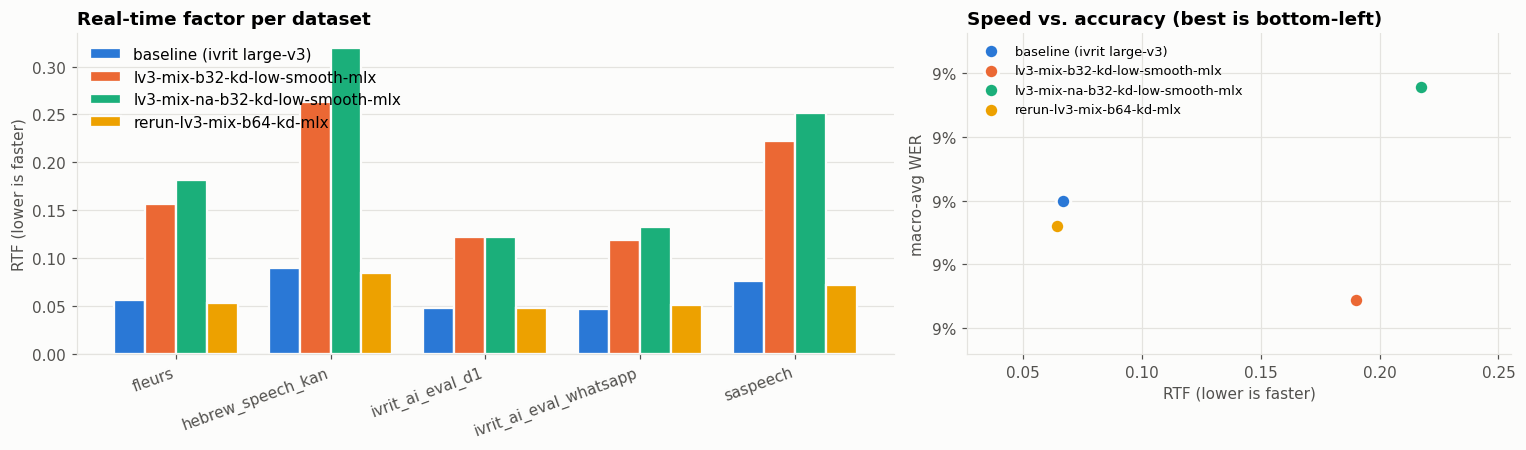

model_name,baseline (ivrit large-v3),lv3-mix-b32-kd-low-smooth-mlx,lv3-mix-na-b32-kd-low-smooth-mlx,rerun-lv3-mix-b64-kd-mlx
dataset_name,,,,
fleurs,0.056,0.157,0.182,0.053
hebrew_speech_kan,0.089,0.263,0.319,0.085
ivrit_ai_eval_d1,0.048,0.122,0.122,0.048
ivrit_ai_eval_whatsapp,0.047,0.119,0.132,0.051
saspeech,0.076,0.222,0.251,0.072


In [12]:
rtf = raw.groupby(["dataset_name", "model_name"]).apply(
    lambda g: g["transcription_time"].sum() / g["audio_duration"].sum(), include_groups=False
).unstack()[MODELS]
rtf_common = sub.groupby("model_name").apply(
    lambda g: g["transcription_time"].sum() / g["audio_duration"].sum(), include_groups=False
)[MODELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [3, 2]})
for i, m in enumerate(MODELS):
    ax1.bar(x - 0.4 + width * (i + 0.5), rtf.loc[DATASETS, m], width, color=COLOR[m], label=label(m),
            edgecolor=SURFACE, linewidth=1.5)
ax1.set_xticks(x, DATASETS, rotation=20, ha="right")
ax1.set_ylabel("RTF (lower is faster)")
ax1.set_title("Real-time factor per dataset")
ax1.legend(loc="upper left")

for m in MODELS:
    ax2.scatter(rtf_common[m], board.loc["avg (macro)", m], s=90, color=COLOR[m], edgecolor=SURFACE, linewidth=2,
                zorder=3, label=label(m))
ax2.legend(loc="upper left", fontsize=8.5)
ax2.yaxis.set_major_formatter(pct)
ax2.set_xlabel("RTF (lower is faster)")
ax2.set_ylabel("macro-avg WER")
ax2.set_title("Speed vs. accuracy (best is bottom-left)")
ax2.grid(True, axis="both")
ax2.margins(0.25)
plt.tight_layout()
plt.show()

display(rtf.rename(columns=label).style.format("{:.3f}", na_rep="n/a"))

## 10. Biggest improvements and regressions (qualitative)
Metrics don't tell you *what* changed, so read the actual transcripts. Pick a model and a dataset. The table
lists the utterances where it gained or lost the most errors vs. the baseline.

In [13]:
COMPARE_MODEL = others[0]
COMPARE_DATASET = COMMON_DATASETS[0]
TOP_N = 8

cols = ["id", "norm_reference_text", "norm_predicted_text", "n_errors", "audio_duration"]
a = raw.query("dataset_name == @COMPARE_DATASET and model_name == @BASELINE")[cols]
b = raw.query("dataset_name == @COMPARE_DATASET and model_name == @COMPARE_MODEL")[cols[:1] + cols[2:4]]
j = a.merge(b, on="id", suffixes=("_base", "_model"))
j["Δerrors"] = j["n_errors_model"] - j["n_errors_base"]
j = j.rename(columns={"norm_reference_text": "reference", "norm_predicted_text_base": "baseline", "norm_predicted_text_model": "model"})
show = ["id", "Δerrors", "reference", "baseline", "model", "audio_duration"]

with pd.option_context("display.max_colwidth", 200):
    print(f"{label(COMPARE_MODEL)} vs. baseline on {COMPARE_DATASET}")
    print("\nBiggest improvements:")
    display(j.nsmallest(TOP_N, "Δerrors")[show])
    print("Biggest regressions:")
    display(j.nlargest(TOP_N, "Δerrors")[show])

lv3-mix-b32-kd-low-smooth-mlx vs. baseline on fleurs

Biggest improvements:


,id,Δerrors,reference,baseline,model,audio_duration
725,725,-4,הסופה העשירית בעונת ההוריקנים האטלנטית שנקראה הסופה התת טרופית גרי אשר נוצרה באוקיינוס האטלנטי היום,חשופה העשירית בעונת האוריקנים האטלנטיים שנקראה חשופה תת טרופית גרי אשר נוצרה באוקיינוס האטלנטי היום,הסופה העשירית בעונת ההוריקנים האטלנטיים שנקראה הסופה התת טרופית גרי אשר נוצרה באוקיינוס האטלנטי היום,9.18
19,19,-3,לסין העתיקה הייתה דרך משלה להציג תקופות זמן שונות כל שלב בתולדות סין או כל משפחה שהחזיקה בשלטון הייתה שושלת ייחודית,בסין העתיקה הייתה דריך משלל להציג תוקפות זמנות שונות כל שלב בטובלוצין וכל משפחה שהייתה מקבלת שונות הייתה שושלת ייחודית,בסין העתיקה הייתה דריך משלל להציג תגובות זמן שונות כל שלב בתולדות סין וכל משפחה שהייתה מקבלת שכונות הייתה שושלת ייחודית,5.88
341,341,-3,עמק קוצאמו יעד הטיפוס העיקרי של צילה ידוע בתור יוסמיטי של דרום אמריקה עם מגוון של קירות וצוקי גרניט גדולים,עמק אוצאמו הוא יעד הטיפוס העיקרי של ציל הידוע בתור יוסינטי של דרום אמריקה עם מגוון של גירות וצוקי גרנית גדולים,עמק הוצאמו הוא יעד הטיפוס העיקרי של צילה ידוע בתור יוסימטי של דרום אמריקה עם מגוון של גירות וצוקי גרניט גדולים,7.44
527,527,-3,יער סונדרבאנס הוכרז כאתר מורשת עולמי מטעם יונסק ו חלק היער שבתוך הטריטוריה ההודית נקרא הפארק הלאומי סונדרבאנס,ירק סונדרבנס הוא חצי האתר מורשת עולמים מטעם יונסקו חלק הירק שבתוך הטריטוריה ההודית נקרא פארק הלאומי סונדרבנס,יער סונדרבנס הוחצה לאתר מורשת עולמים מטעם יונסקו חלק היער שבתוך הטריטוריה ההודית נקרא פארק הלאומי סונדרבנס,6.54
71,71,-2,אלו חופי משפחות שלעתים עמוסים עם מגוון נהדר של חנויות לאורך החוף השחייה בטוחה,אלו חופי משפחות שלעיתים עמוסים עם מגוון נהדר של חנויות לאורך החוף הזכייה בתוכה,אלו חופי משפחות שלעתים עמוסים עם מגוון נהדר של חנויות לאורך החוף הזכייה בטוחה,10.56
110,110,-2,הרכב עצמו נלקח מזירת התאונה באותו יום בסביבות 12 00 שעון גריניץ,הרכב הצימוני לקח מזירת התנועה באותו יום בסביבות 12 שעון גריניץ,הרכב עצמו נלקח מזירת התנועה באותו יום בסביבות 12 שעון גריניץ,11.28
114,114,-2,הוא דק יותר מתחת לימות ועבה יותר מתחת לרמות,הודק יותר מתחת לימות והביא יותר מתחת לרמות,הוא דק יותר מתחת לימות והווה יותר מתחת לרמות,3.36
152,152,-2,אין הגדרה אוניברסלית הקובעת אילו מוצרים נחשבים עתיקות גופי מיסוי מסוימים מגדירים סחורות בנות למעלה ממאה שנה עתיקות,אין הגדרה אוניברסלית הקובעת אילו מוצרים נחשבים עתיקות גופי מיסוי מסוימים מגדירים סחורות בנות למעלה מ 100 שנה עתיקות,אין הגדרה אוניברסלית הקובעת אילו מוצרים נחשבים עתיקות גופי מיסוי מסוימים מגדירים סחורות בנות למעלה ממאה שנה עתיקות,10.08


Biggest regressions:


,id,Δerrors,reference,baseline,model,audio_duration
322,322,4,החובטים מהמסדר האמצעי סאצין טנדולקר וראול דראוויד תפקדו היטב ויצרו שותפות של מאה נקודות,הרובטים מהמסדר האמצעי סאצין טרונגר וראול דראביד תפקדו היטב ויצרו שותפות של 100 נקודות,אך אופטימיה מסדר אמצעי סאצינג טרונגר וראול דראביט תפקדו היטב ויצרו שותפות של 100 נקודות,5.46
21,21,3,בנוסף מצפון תוכלו לבקר במשכן הגדול של גבירתנו מפטימה מקדש מקום בו התרחשו התגלויות של מריה המפורסמות ברחבי העולם,בנוסף מצפון תוכלו לבקר במשכן הגדול של גבירתנו מפתימה מקום שבו התרחשו התגלויות של מליאה המפורסמות ברחבי העולם,בנוסף מצפון תוכלו לבקר במשכן הגדול של גבירתנו מפתימה מקום שבו התרחשות גלויות של מליאה מפורסמות ברחבי העולם,8.28
311,311,3,היא קשורה אך בדרך כלל אינה מערבת סקי בסגנון אלפיני או טיפוס הרים האחרונים מבוצעים בשטחים תלולים והם דורשים מגפיים ומגלשיים קשיחים הרבה יותר,כשהוא רך בדרך כלל אינם ערבי צקי בסגנון אלפיני או טיפוס ערים האחרונים מבוצעים משטחים תלויים והם דורשים אגפה ממגלשיים צודקים הרבה יותר,כשהוא רך בדרך כלל אינם מערב יצקי בסגנון אלפים הוא טיפוס הרי מאחרונים מבוצעים משטחים תלויים והם דורשים אגפה ממגלשיים צודקים הרבה יותר,7.92
579,579,3,זרמים נסוגים הם הזרימה החוזרת מגלים הנשברים על החוף לעיתים קרובות בשונית וכדומה,זרימה אחר כך מגלים ונשברים על החוף לרקתים קרובות בישונית או אדומה,זאת מן הסוגים עם זרימה חרוזה עד מגנים הנשברים על החוף של ריקטים קרובות בישונית או אדומים,4.62
145,145,2,מספר הנוכחים היה כה גדול עד שהיה בלתי אפשרי עבור כולם להגיע ללוויה בכיכר פטרוס הקדוש,מספר הנוכחים היה כה גדול עד שהיה בלתי אפשרי עבור כולם להגיד לוואה בקרע פטרוס הקדוש,מספר הנוחתים היה כה גדול שהיה בלתי אפשרי עבור כולם להגיד לביאה בקיר פטרוס הקדוש,4.44
179,179,2,במרחק קצר לכיוון צפון תוכלו למצוא את העיירה הרומנטית והמרתקת סינטרה שנודעה לזרים בעקבות תיאור זוהר של יופייה שכתב לורד ביירון,במחקר קצר לכיוון צפון תוכלו למצוא את העיר הרומנית ואת מדריצים טראשנל לזרים בעקבות תיאור זוהר של יופיה שכתב לוורד ביון,במחקר קצר לכיוון צפון תוכלו למצוא את העיר הרומנית במדריצים קטנים של מדרש זרים בעקבות תיאור זוהר של יופיה שכתב לווד ביון,6.72
230,230,2,אנחנו מסכימים עם הצהרת הוועד האולימפי של ארה ב שטובתם של הספורטאיות והמועדונים שלנו וענפי הספורט שלהם תקודם טוב יותר אם נפעל לשינוי משמעותי בארגוננו ולא על ידי שלילת הרישיון,אנחנו מסכימים עם הצהרת הוועד האולימפי של ארה ב שטובתם של הספורטאיות והמועדונים שלנו וענפי הספורט שלהם תקודם טוב יותר אם נפעל לשינוי משמעותי בארגוננו ולא על ידי שלילת הרישיון,אנחנו מסכימים להצהרת הוועד האולימפי של ארה ב שטובתם של הספורטאיות והמועדונים שלנו וענפי הספורט שלהם תקודם טוב יותר אם נפעל לשינוי משמעותי בארגוננו ולא על ידי שלילת הרישיון,11.34
234,234,2,עבור הספרינגבוקס המשחק קטע רצף של חמישה הפסדים,עבור הספרינגבוקס המשחק קטע רצף של חמישה הפסידים,עבור הספרינג פוקס המשחק קטע רצף של חמישה הפסידים,7.50
